In [5]:
import numpy as np

from jax import random
import jax.numpy as jnp

import numpyro
import numpyro.distributions as dist
from numpyro import infer
numpyro.set_host_device_count(2)

import arviz as az

In [4]:
!head -60 ../data/co2_mm_mlo.txt | tail -n 10

 1958   11   1958.8740      313.33      315.21     -1   -9.99   -0.99
 1958   12   1958.9562      314.67      315.43     -1   -9.99   -0.99
 1959    1   1959.0411      315.58      315.52     -1   -9.99   -0.99
 1959    2   1959.1260      316.49      315.84     -1   -9.99   -0.99
 1959    3   1959.2027      316.65      315.37     -1   -9.99   -0.99
 1959    4   1959.2877      317.72      315.42     -1   -9.99   -0.99
 1959    5   1959.3699      318.29      315.46     -1   -9.99   -0.99
 1959    6   1959.4548      318.15      316.00     -1   -9.99   -0.99
 1959    7   1959.5370      316.54      315.87     -1   -9.99   -0.99
 1959    8   1959.6219      314.80      316.09     -1   -9.99   -0.99


In [ ]:
data = np.genfromtxt('../data/co2_mm_mlo.txt', comments='#')

In [9]:
date = data[:, 2]
co2 = data[:, 3]
uncert = data[:, -1]
missing_uncert = uncert == -0.99

In [11]:
import matplotlib.pyplot as plt

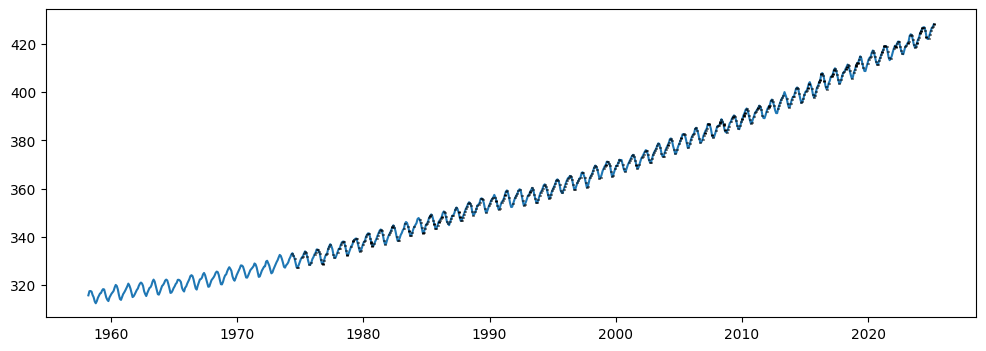

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(date, co2)
plt.errorbar(
    date[~missing_uncert],
    co2[~missing_uncert],
    yerr=uncert[~missing_uncert],
    lw=0, elinewidth=2, color='k'
);

In [14]:
date_offset = date[0]
date -= date_offset

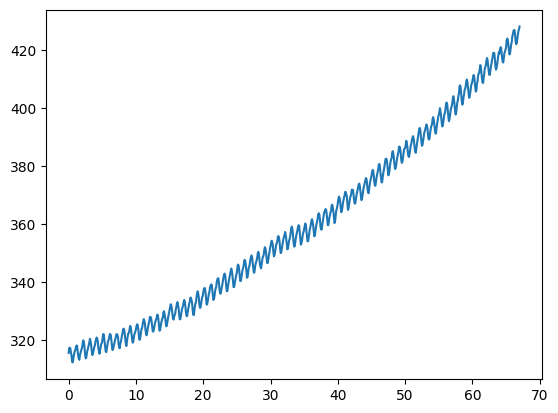

In [15]:
plt.plot(date, co2)